# Orders Data Summary — 4 Figures (4 Subplots Each)

This notebook loads `Orders.csv`, computes revenue/profit fields, and produces four summary figures:
1. Category Performance
2. Time Trends
3. Geographic Distribution
4. Order Status, Discounts & Top Sales Performers

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

In [2]:
# Load & prepare data
# df = pd.read_csv('data/Orders.csv')
df =pd.read_csv('./data/Orders.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d/%m/%Y")
df['Total_Revenue'] = df['Quantity'] * df['Unit Price'] - df['Discount']
df['Net_Profit'] = df['Total_Revenue'] - df['Total Cost']
df['Year_Month'] = df['Order Date'].dt.strftime('%Y-%m')
df['Status_Label'] = df['Status'].map({True: 'Completed', False: 'Cancelled'})

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

df.head()

,Order ID,Order Date,Day,Country,City,Lat,Lng,Full Name,Category,Sub Category,...,SalesPerson ID,Quantity,Unit Price,Discount,Total Cost,Status,Total_Revenue,Net_Profit,Year_Month,Status_Label
0,1,2023-01-01,Mon,Syria,homs,34.7326,36.7136,Lina Alrrashid,Tablet,Apple iPad,...,N498,4,999,38.3616,891.9072,False,3957.6384,3065.7312,2023-01,Cancelled
1,2,2023-01-01,Tue,Saudi Arabia,riyadh,24.7136,46.6753,Omar Eurul,Smartphone,Samsung Galaxy,...,X918,3,1199,517.9680,302.1480,True,3079.0320,2776.8840,2023-01,Completed
2,3,2023-01-01,Tue,Saudi Arabia,riyadh,24.7743,46.7386,Iman Iismaeil,Digital Camera,Panasonic Lumix,...,I036,4,1299,883.3200,831.3600,True,4312.6800,3481.3200,2023-01,Completed
3,4,2023-01-01,Mon,United Arab Emirates,abu dhabi,24.4539,54.3773,Ahmad Rihan,Tablet,Samsung Galaxy Tab,...,E804,6,199,33.3126,129.5490,True,1160.6874,1031.1384,2023-01,Completed
4,5,2023-01-01,Wed,USA,washington,38.9072,-77.0369,Sami Altawil,Headphones,Sennheiser HD,...,Q149,4,129,11.2617,111.3657,True,504.7383,393.3726,2023-01,Completed


In [4]:
def fmt_thousands(ax, axis='x'):
    formatter = mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
    if axis == 'x':
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

def annotate_bars(ax, horizontal=True, fmt='{:,.0f}'):
    for p in ax.patches:
        if horizontal:
            width = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ax.text(width, y, ' ' + fmt.format(width), va='center', ha='left', fontsize=9)
        else:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax.text(x, height, fmt.format(height), va='bottom', ha='center', fontsize=9)

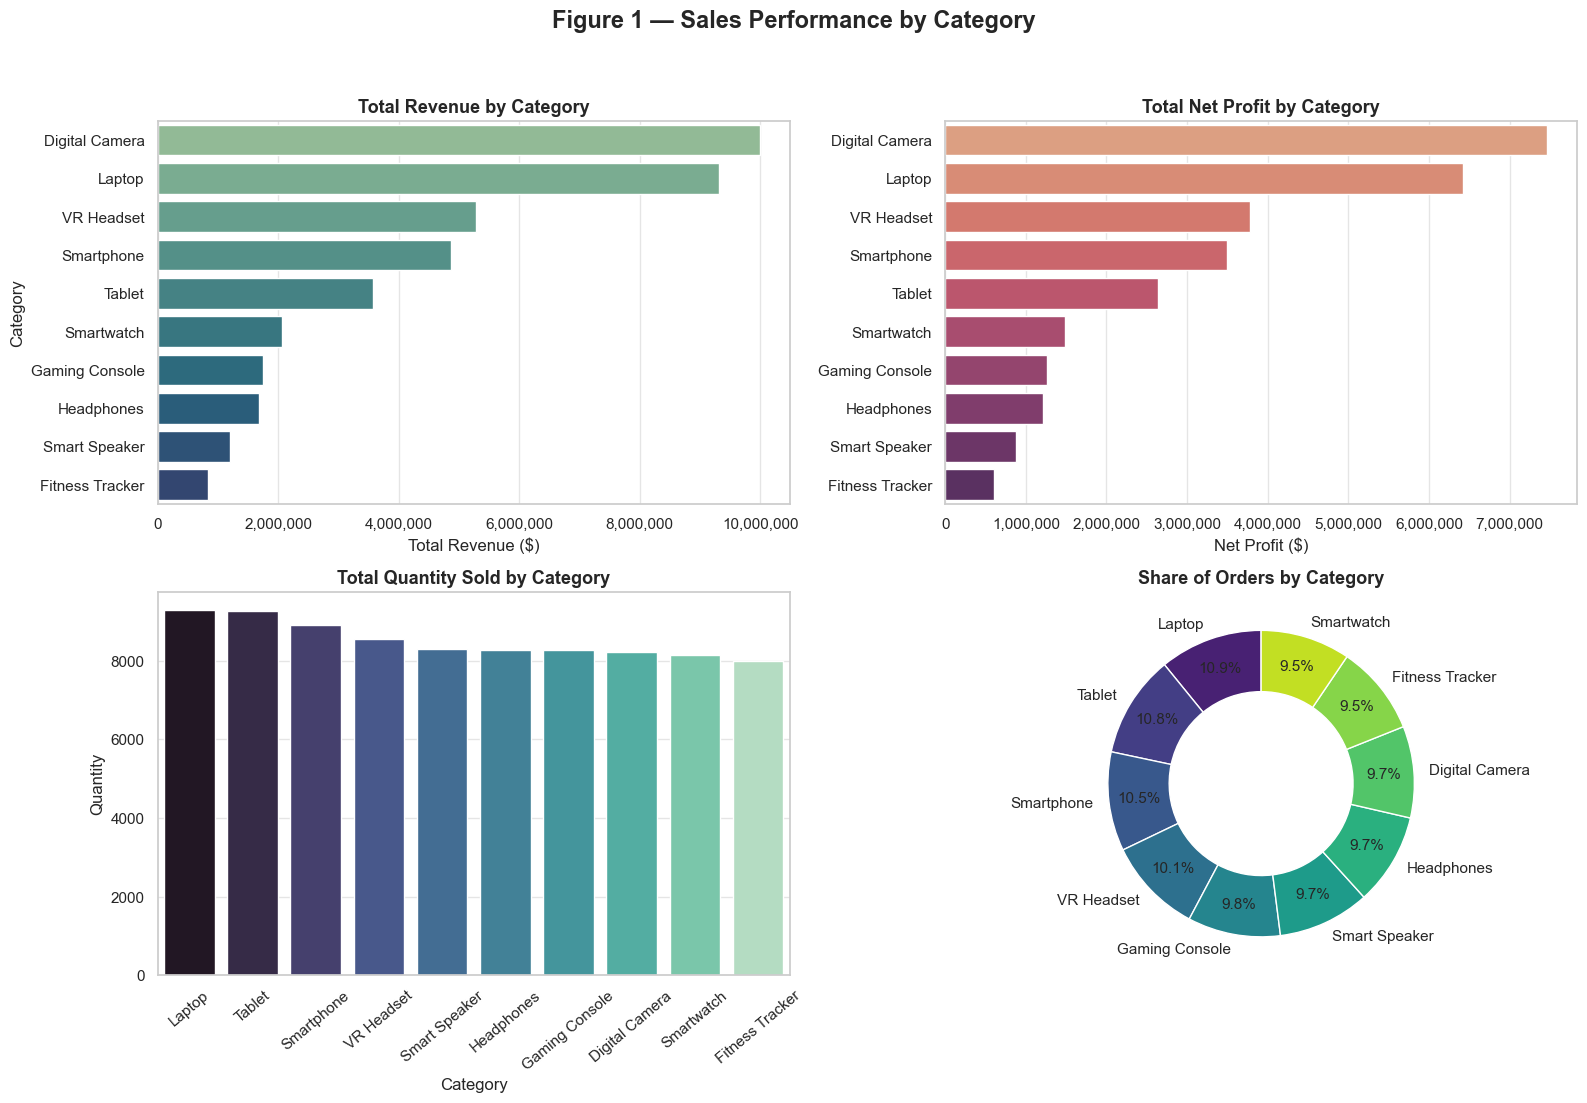

In [5]:
# ================= FIGURE 1: Category Performance =================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 1 — Sales Performance by Category', fontsize=17, fontweight='bold', y=1.0)

cat_rev = df.groupby('Category')['Total_Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, ax=axes[0,0], hue=cat_rev.index, palette='crest', legend=False)
axes[0,0].set_title('Total Revenue by Category')
axes[0,0].set_xlabel('Total Revenue ($)')
axes[0,0].set_ylabel('Category')
fmt_thousands(axes[0,0], 'x')

cat_profit = df.groupby('Category')['Net_Profit'].sum().sort_values(ascending=False)
sns.barplot(x=cat_profit.values, y=cat_profit.index, ax=axes[0,1], hue=cat_profit.index, palette='flare', legend=False)
axes[0,1].set_title('Total Net Profit by Category')
axes[0,1].set_xlabel('Net Profit ($)')
axes[0,1].set_ylabel('')
fmt_thousands(axes[0,1], 'x')

cat_qty = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=cat_qty.index, y=cat_qty.values, ax=axes[1,0], hue=cat_qty.index, palette='mako', legend=False)
axes[1,0].set_title('Total Quantity Sold by Category')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Quantity')
axes[1,0].tick_params(axis='x', rotation=40)

cat_orders = df['Category'].value_counts()
colors = sns.color_palette('viridis', len(cat_orders))
axes[1,1].pie(cat_orders.values, labels=cat_orders.index, autopct='%1.1f%%',
              colors=colors, startangle=90, pctdistance=0.8,
              wedgeprops=dict(width=0.4, edgecolor='white'))
axes[1,1].set_title('Share of Orders by Category')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

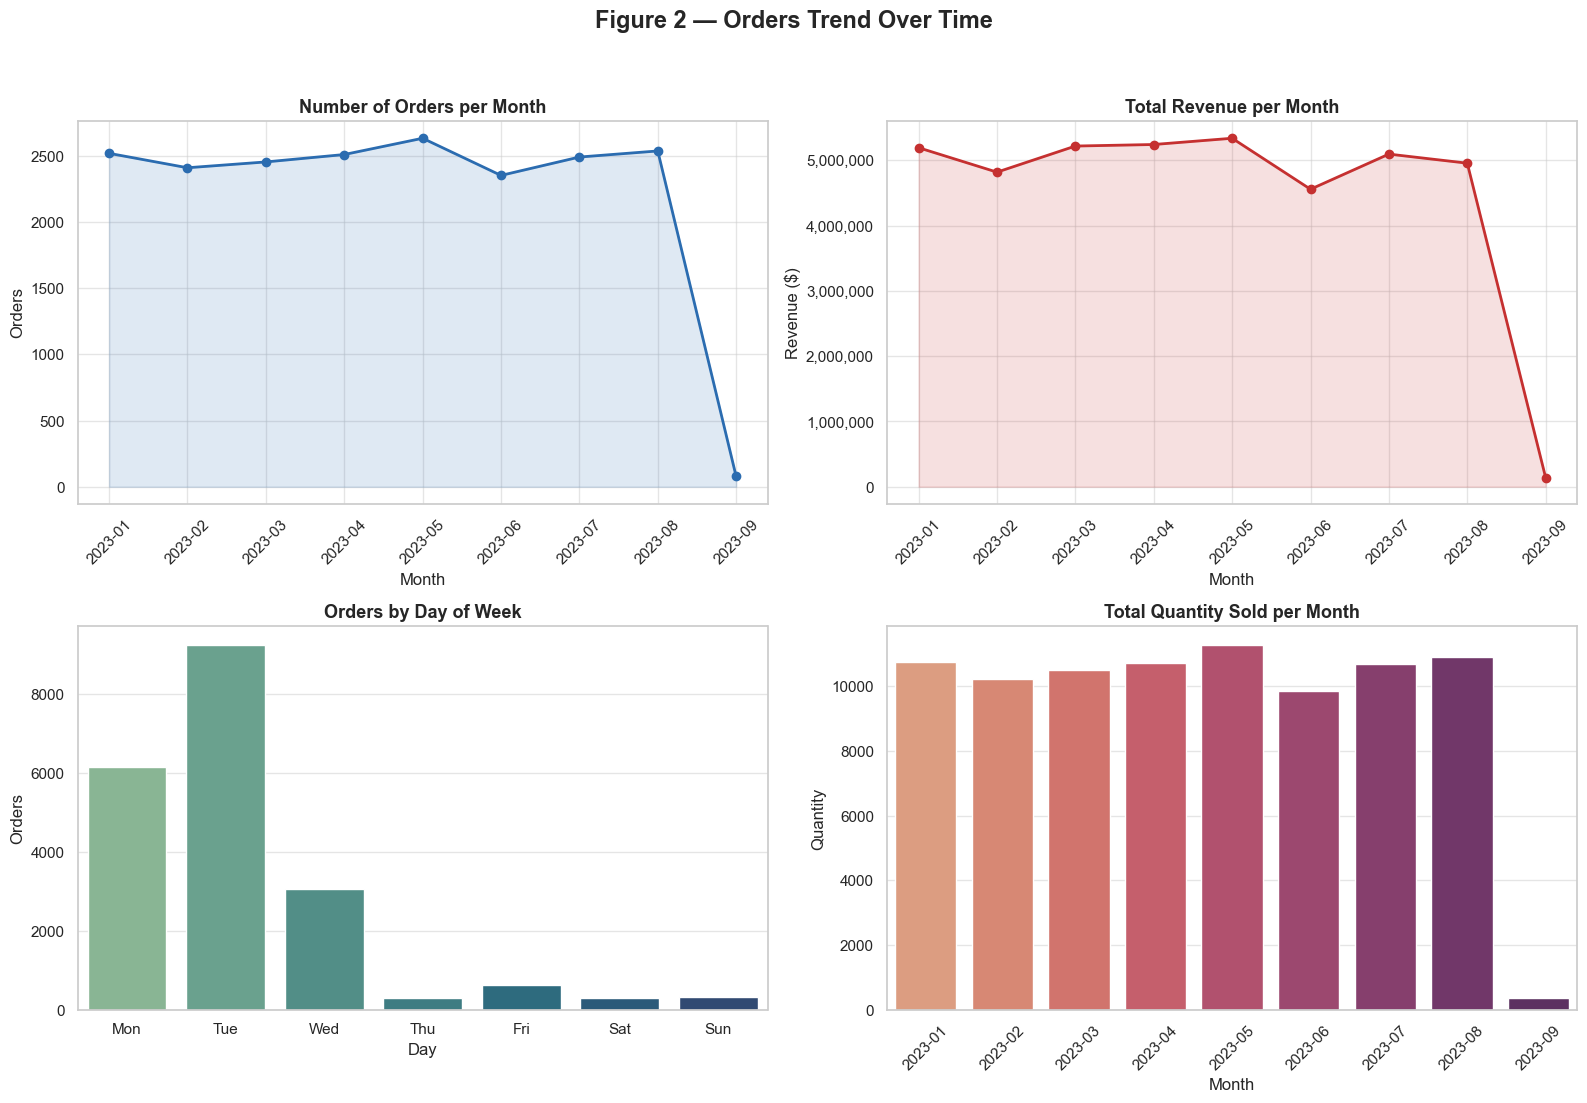

In [6]:
# ================= FIGURE 2: Time Trends =================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 2 — Orders Trend Over Time', fontsize=17, fontweight='bold', y=1.0)

monthly_orders = df.groupby('Year_Month').size()
axes[0,0].plot(monthly_orders.index, monthly_orders.values, marker='o', color='#2b6cb0', linewidth=2)
axes[0,0].set_title('Number of Orders per Month')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Orders')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].fill_between(monthly_orders.index, monthly_orders.values, alpha=0.15, color='#2b6cb0')

monthly_rev = df.groupby('Year_Month')['Total_Revenue'].sum()
axes[0,1].plot(monthly_rev.index, monthly_rev.values, marker='o', color='#c53030', linewidth=2)
axes[0,1].set_title('Total Revenue per Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Revenue ($)')
axes[0,1].tick_params(axis='x', rotation=45)
fmt_thousands(axes[0,1], 'y')
axes[0,1].fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#c53030')

day_counts = df['Day'].value_counts().reindex(day_order)
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[1,0], hue=day_counts.index, palette='crest', legend=False)
axes[1,0].set_title('Orders by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Orders')

monthly_qty = df.groupby('Year_Month')['Quantity'].sum()
sns.barplot(x=monthly_qty.index, y=monthly_qty.values, ax=axes[1,1], hue=monthly_qty.index, palette='flare', legend=False)
axes[1,1].set_title('Total Quantity Sold per Month')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Quantity')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

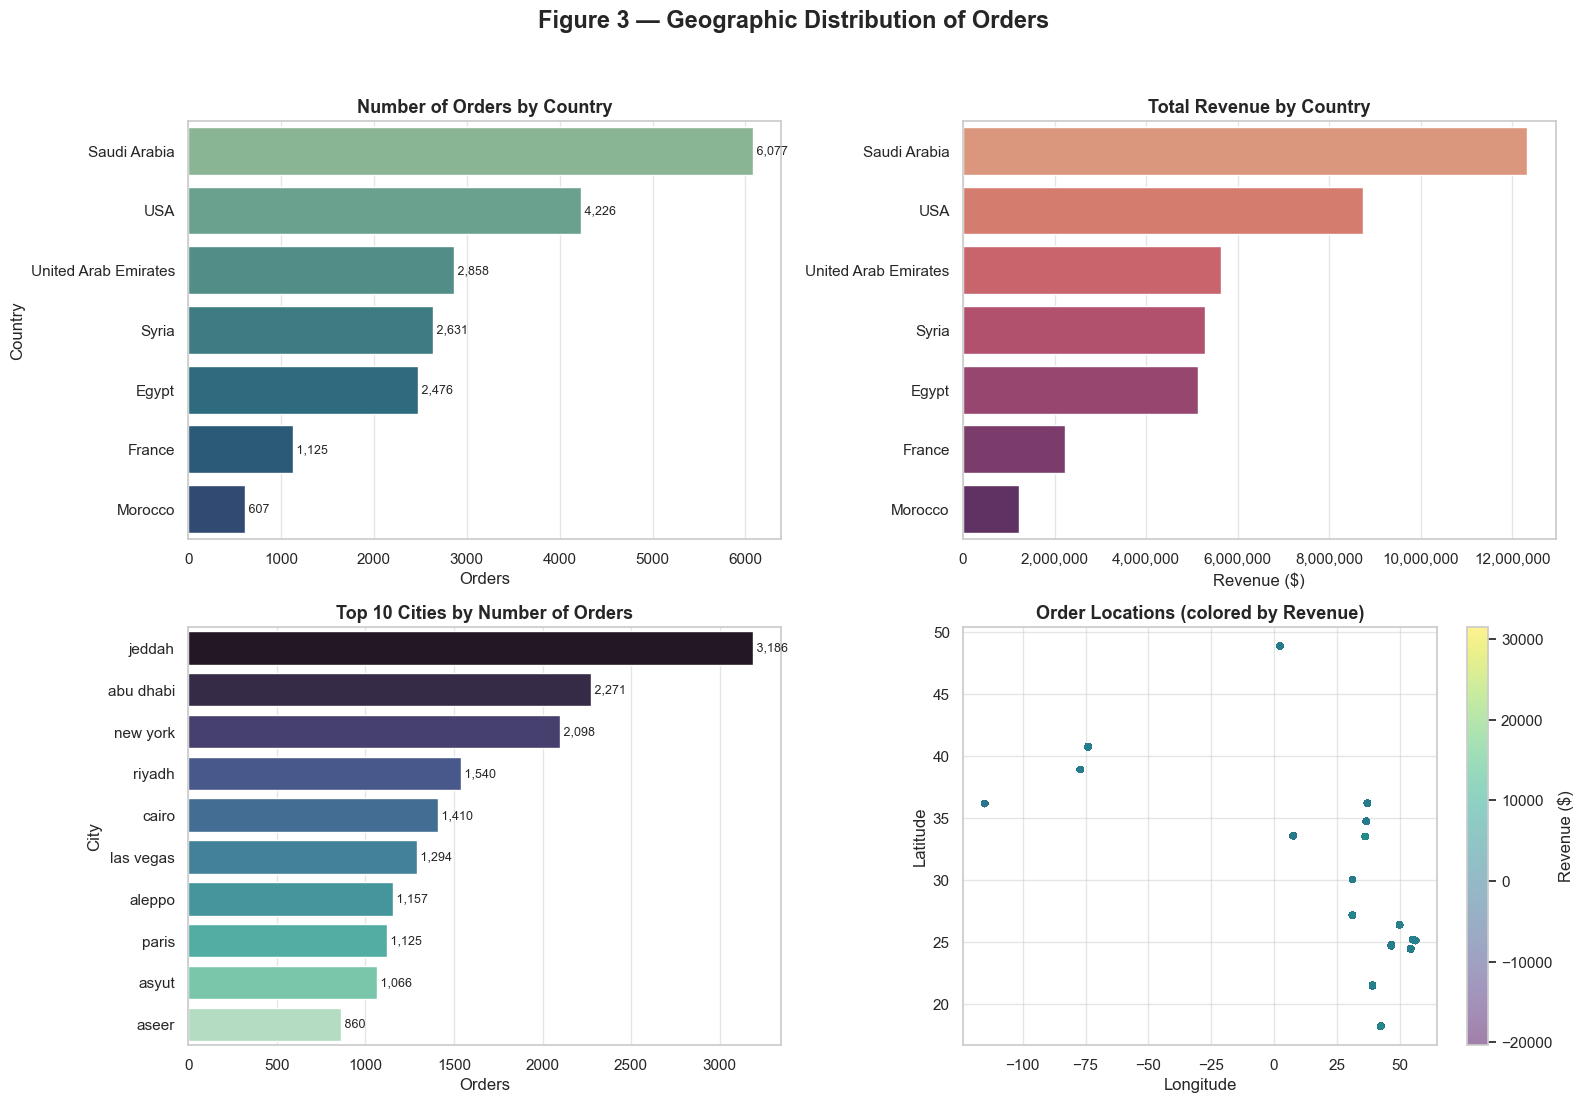

In [7]:
# ================= FIGURE 3: Geography =================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 3 — Geographic Distribution of Orders', fontsize=17, fontweight='bold', y=1.0)

country_orders = df['Country'].value_counts()
sns.barplot(x=country_orders.values, y=country_orders.index, ax=axes[0,0], hue=country_orders.index, palette='crest', legend=False)
axes[0,0].set_title('Number of Orders by Country')
axes[0,0].set_xlabel('Orders')
axes[0,0].set_ylabel('Country')
annotate_bars(axes[0,0], horizontal=True)

country_rev = df.groupby('Country')['Total_Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=country_rev.values, y=country_rev.index, ax=axes[0,1], hue=country_rev.index, palette='flare', legend=False)
axes[0,1].set_title('Total Revenue by Country')
axes[0,1].set_xlabel('Revenue ($)')
axes[0,1].set_ylabel('')
fmt_thousands(axes[0,1], 'x')

city_orders = df['City'].value_counts().head(10)
sns.barplot(x=city_orders.values, y=city_orders.index, ax=axes[1,0], hue=city_orders.index, palette='mako', legend=False)
axes[1,0].set_title('Top 10 Cities by Number of Orders')
axes[1,0].set_xlabel('Orders')
axes[1,0].set_ylabel('City')
annotate_bars(axes[1,0], horizontal=True)

scatter = axes[1,1].scatter(df['Lng'], df['Lat'], c=df['Total_Revenue'], cmap='viridis',
                             s=25, alpha=0.5, edgecolor='none')
axes[1,1].set_title('Order Locations (colored by Revenue)')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
cbar = plt.colorbar(scatter, ax=axes[1,1])
cbar.set_label('Revenue ($)')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

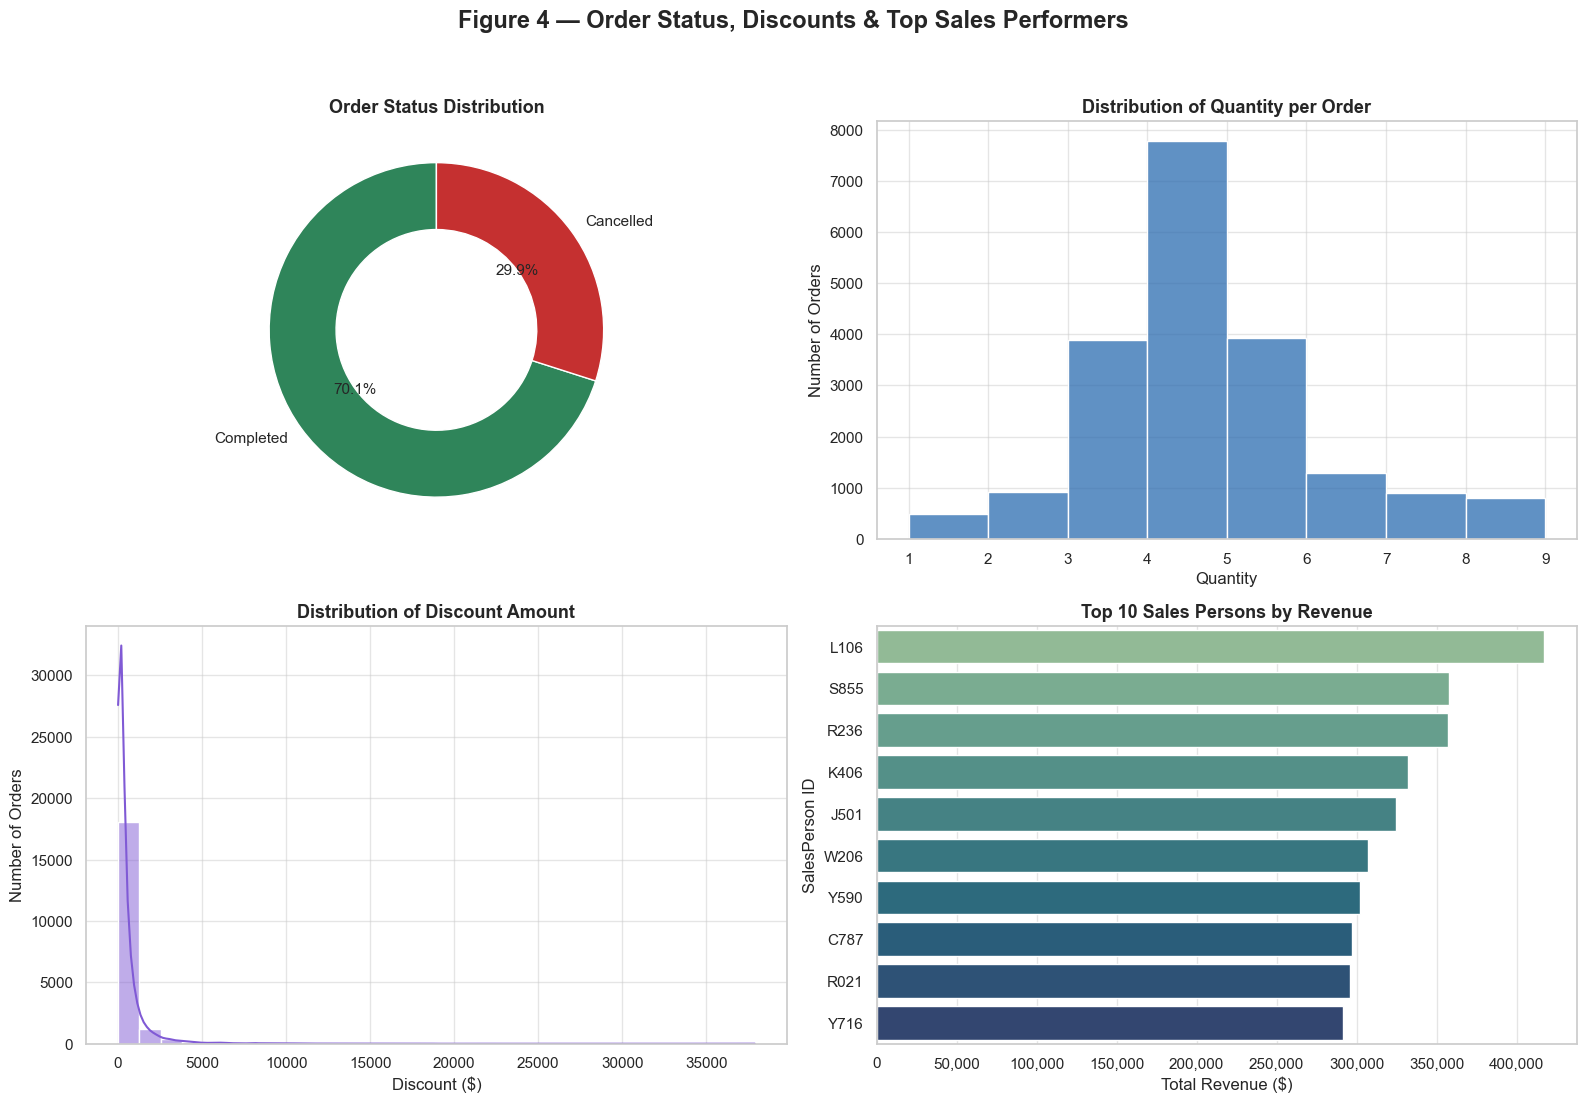

In [8]:
# ================= FIGURE 4: Orders Quality & Sales Team =================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 4 — Order Status, Discounts & Top Sales Performers', fontsize=17, fontweight='bold', y=1.0)

status_counts = df['Status_Label'].value_counts()
colors_status = ['#2f855a', '#c53030']
axes[0,0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
              colors=colors_status, startangle=90,
              wedgeprops=dict(width=0.4, edgecolor='white'))
axes[0,0].set_title('Order Status Distribution')

sns.histplot(df['Quantity'], bins=range(1, df['Quantity'].max()+2), ax=axes[0,1], color='#2b6cb0', kde=False)
axes[0,1].set_title('Distribution of Quantity per Order')
axes[0,1].set_xlabel('Quantity')
axes[0,1].set_ylabel('Number of Orders')

sns.histplot(df['Discount'], bins=30, ax=axes[1,0], color='#805ad5', kde=True)
axes[1,0].set_title('Distribution of Discount Amount')
axes[1,0].set_xlabel('Discount ($)')
axes[1,0].set_ylabel('Number of Orders')

top_sales = df.groupby('SalesPerson ID')['Total_Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_sales.values, y=top_sales.index, ax=axes[1,1], hue=top_sales.index, palette='crest', legend=False)
axes[1,1].set_title('Top 10 Sales Persons by Revenue')
axes[1,1].set_xlabel('Total Revenue ($)')
axes[1,1].set_ylabel('SalesPerson ID')
fmt_thousands(axes[1,1], 'x')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()